In [2]:
# First, install the xgboost package
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# First, let's check what's going on with xgboost
import sys
print("Python version:", sys.version)
print("Python executable:", sys.executable)

# Check installed packages
!pip list | grep xgboost

# Try reinstalling xgboost
!pip uninstall -y xgboost
!pip install xgboost

# If you're using Anaconda, you can try:
# !conda install -y -c conda-forge xgboost

# Now try importing again
try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
    print("XGBoost successfully imported")
except ImportError as e:
    print("Error importing XGBoost:", e)
# Continue with your original code if the import works

Python version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
Python executable: C:\ProgramData\anaconda3\python.exe


'grep' is not recognized as an internal or external command,
operable program or batch file.


Found existing installation: xgboost 3.0.2
Uninstalling xgboost-3.0.2:
  Successfully uninstalled xgboost-3.0.2
Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.0.2-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.0.2-py3-none-win_amd64.whl (150.0 MB)
XGBoost version: 3.0.2
XGBoost successfully imported


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
dataset = pd.read_csv('Social_Network_Ads.csv')

# Select features and target
X = dataset[['Age', 'EstimatedSalary']].values
y = dataset['Purchased'].values

In [5]:
# Split into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# If xgboost import still fails, let's use a different classifier as fallback
try:
    from xgboost import XGBClassifier
    classifier = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0)
    print("Using XGBoost classifier")
except ImportError:
    # Fallback to RandomForest if XGBoost is not available
    from sklearn.ensemble import RandomForestClassifier
    classifier = RandomForestClassifier(n_estimators=100, random_state=0)
    print("Falling back to RandomForest classifier")


Using XGBoost classifier


C:\Users\maahi\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [19:43:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:
 [[63  5]
 [ 5 27]]
Accuracy Score: 0.9
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        68
           1       0.84      0.84      0.84        32

    accuracy                           0.90       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.90      0.90      0.90       100



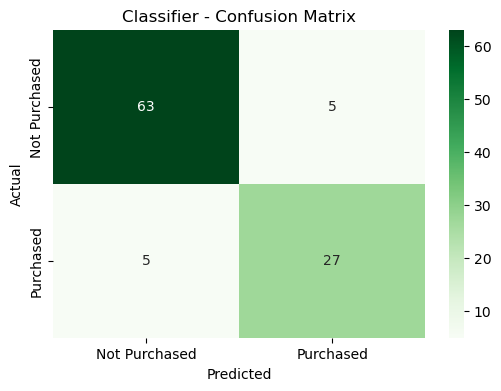

In [6]:

# Train the classifier
classifier.fit(X_train, y_train)

# Predict on test data
y_pred = classifier.predict(X_test)

# Evaluation
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy Score
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot confusion matrix heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Not Purchased', 'Purchased'], yticklabels=['Not Purchased', 'Purchased'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Classifier - Confusion Matrix')
plt.show()